# Fig_EEG_Main_VARvsBBvsPersist_MSE_AB (Notebook)

This notebook is a Jupyter-friendly version of `Fig_EEG_Main_VARvsBBvsPersist_MSE_AB.py`.

It **only** needs the 6 result files that contain MSE-vs-horizon curves (stored in `.pt/.pth` or `.npz`).

## What to do
1. Edit the **Config** cell below to point to your 6 files.
2. Run all cells.
3. The figure will be saved to `OUT_PATH`.


In [11]:
# ----------------------------
# Config (EDIT ME)
# ----------------------------
from pathlib import Path

# Input files (must exist)
VAR_W9S1      = Path("results/VAR_eeg_center_W9s1.pt")
VAR_W25S5     = Path("results/var_eeg_center_w25s5.pt")
BB_W9S1       = Path("results/bb_mse_W9s1.pt")
BB_W25S5      = Path("results/bb_mse_W25s5.pt")
PERSIST_W9S1  = Path("results/persist_mse_W9s1.pt")
PERSIST_W25S5 = Path("results/persist_mse_W25s5.pt")

# If your files use non-standard keys, set these. Otherwise keep None.
VAR_KEY = None
BB_KEY = None
PERSIST_KEY = None

# Plot/save settings
OUT_PATH = Path("figures/Figure1.png")
DPI = 300
FONTSIZE = 11
YSCALE = "linear"   # 'linear' or 'log'

# Polish controls
LEGEND_PANEL = "a"      # 'a', 'b', or 'none'
LEGEND_LOC = "lower right"
AUTO_YLIM_PER_PANEL = True


In [12]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import torch


In [13]:
def _to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _load_any(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(str(path))
    if path.suffix in [".pt", ".pth"]:
        return torch.load(path, map_location="cpu")
    if path.suffix == ".npz":
        return dict(np.load(path, allow_pickle=True))
    raise ValueError(f"Unsupported file type: {path}")


def load_mse_curve(path, key=None):
    d = _load_any(path)
    if key is not None:
        return _to_numpy(d[key]).astype(np.float64).reshape(-1)

    candidates = [
        "val_mse_by_k_eeg",
        "mse_by_k_eeg",
        "mse_eeg_by_k",
        "mse_by_k",
        "val_mse_by_k",
    ]
    for k in candidates:
        if k in d:
            return _to_numpy(d[k]).astype(np.float64).reshape(-1)
    raise KeyError(
        f"Could not auto-detect MSE curve key in {path}. "
        f"Keys head: {list(d.keys())[:50]}"
    )


def robust_ylim(y_list, yscale="linear", lo_q=2.0, hi_q=98.0, pad_frac=0.06):
    """Compute robust y-limits from a list of 1D arrays."""
    y = np.concatenate([np.asarray(a, dtype=np.float64).reshape(-1) for a in y_list])
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None

    lo = np.percentile(y, lo_q)
    hi = np.percentile(y, hi_q)

    if yscale == "log":
        lo = max(lo, 1e-12)
        hi = max(hi, lo * 10.0)

    span = hi - lo
    if span <= 0:
        span = abs(hi) if hi != 0 else 1.0
    lo2 = lo - pad_frac * span
    hi2 = hi + pad_frac * span
    if yscale == "log":
        lo2 = max(lo2, 1e-12)
    return lo2, hi2


def add_panel_text(ax, panel_label, subtitle, label_xy=(0.02, 0.95), sub_xy=(0.02, 0.87)):
    bbox_kw = dict(facecolor="white", alpha=0.70, edgecolor="none", boxstyle="round,pad=0.25")
    ax.text(*label_xy, panel_label, transform=ax.transAxes, va="top", ha="left",
            fontsize=13, fontweight="bold", bbox=bbox_kw)
    ax.text(*sub_xy, subtitle, transform=ax.transAxes, va="top", ha="left",
            fontsize=11, bbox=bbox_kw)


In [14]:
# Load curves
y_var_9  = load_mse_curve(VAR_W9S1,  key=VAR_KEY)
y_var_25 = load_mse_curve(VAR_W25S5, key=VAR_KEY)
y_bb_9   = load_mse_curve(BB_W9S1,   key=BB_KEY)
y_bb_25  = load_mse_curve(BB_W25S5,  key=BB_KEY)
y_p_9    = load_mse_curve(PERSIST_W9S1,  key=PERSIST_KEY)
y_p_25   = load_mse_curve(PERSIST_W25S5, key=PERSIST_KEY)

# Sanity: lengths must match within each panel
for nm, a, b, c in [
    ("W9s1",  y_var_9,  y_bb_9,  y_p_9),
    ("W25s5", y_var_25, y_bb_25, y_p_25),
]:
    if len(a) != len(b) or len(a) != len(c):
        raise ValueError(f"{nm}: curve lengths differ: VAR={len(a)} BB={len(b)} P={len(c)}")

print("Loaded curves:")
print("  Panel A (W9s1): ", len(y_var_9), "points")
print("  Panel B (W25s5):", len(y_var_25), "points")


Loaded curves:
  Panel A (W9s1):  16 points
  Panel B (W25s5): 16 points


[Saved] figures/Figure1.png


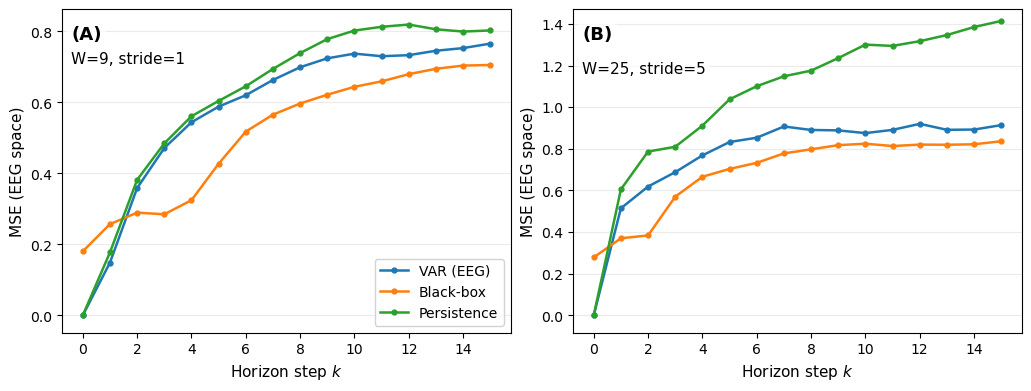

In [15]:
# Plot
plt.rcParams.update({
    "font.size": FONTSIZE,
    "axes.labelsize": FONTSIZE,
    "legend.fontsize": FONTSIZE - 1,
    "xtick.labelsize": FONTSIZE - 1,
    "ytick.labelsize": FONTSIZE - 1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8), constrained_layout=True)

# Panel (A)
k = np.arange(len(y_var_9))
axes[0].plot(k, y_var_9, marker="o", markersize=3.5, linewidth=1.8, label="VAR (EEG)")
axes[0].plot(k, y_bb_9,  marker="o", markersize=3.5, linewidth=1.8, label="Black-box")
axes[0].plot(k, y_p_9,   marker="o", markersize=3.5, linewidth=1.8, label="Persistence")
axes[0].set_xlabel(r"Horizon step $k$")
axes[0].set_ylabel("MSE (EEG space)")
axes[0].set_yscale(YSCALE)
axes[0].grid(True, axis="y", alpha=0.25)
add_panel_text(axes[0], "(A)", "W=9, stride=1")

# Panel (B)
k = np.arange(len(y_var_25))
axes[1].plot(k, y_var_25, marker="o", markersize=3.5, linewidth=1.8, label="VAR (EEG)")
axes[1].plot(k, y_bb_25,  marker="o", markersize=3.5, linewidth=1.8, label="Black-box")
axes[1].plot(k, y_p_25,   marker="o", markersize=3.5, linewidth=1.8, label="Persistence")
axes[1].set_xlabel(r"Horizon step $k$")
axes[1].set_ylabel("MSE (EEG space)")
axes[1].set_yscale(YSCALE)
axes[1].grid(True, axis="y", alpha=0.25)
add_panel_text(axes[1], "(B)", "W=25, stride=5", label_xy=(0.02, 0.95), sub_xy=(0.02, 0.84))

# Legend inside one panel
if LEGEND_PANEL != "none":
    axL = axes[0] if LEGEND_PANEL == "a" else axes[1]
    axL.legend(loc=LEGEND_LOC, frameon=True, framealpha=0.85)

# Per-panel y-lims (optional)
if AUTO_YLIM_PER_PANEL:
    yl0 = robust_ylim([y_var_9, y_bb_9, y_p_9], yscale=YSCALE)
    yl1 = robust_ylim([y_var_25, y_bb_25, y_p_25], yscale=YSCALE)
    if yl0 is not None:
        axes[0].set_ylim(*yl0)
    if yl1 is not None:
        axes[1].set_ylim(*yl1)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PATH, dpi=DPI, bbox_inches="tight")
print("[Saved]", OUT_PATH)

plt.show()


## Notes
- If you plan to distribute this notebook with your repo, consider adding a small `results/` example file so readers can run it without reproducing training.
- If your `.pt` files were saved with CUDA tensors, `map_location='cpu'` should still load them onto CPU.
